In [4]:
import pandas as pd
df = pd.read_excel("customer_churn_dataset.xlsx", sheet_name="Raw_Data")


In [5]:
df.head()

,CustomerID,Age,Gender,Income (Annual),Education,City,Purchase_Amount,Num_Purchases,Churned,Satisfaction_Score,Product_Category,Account_Age_Months
0,1001,28.0,Male,55000.0,Bachelor's,Hyderabad,1200.50,5,0,4.5,Electronics,24
1,1002,NaN,FEMALE,72000.0,masters,mumbai,2300.00,8,0,3.8,Clothing,36
2,1003,35.0,male,48000.0,Bachelor's,Delhi,950.75,3,1,2.1,electronics,12
3,1004,41.0,Female,NaN,PhD,Chennai,3100.00,12,0,4.9,Furniture,48
4,1005,22.0,M,31000.0,High School,Bangalore,420.00,2,1,1.5,clothing,6


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          40 non-null     int64  
 1   Age                 37 non-null     float64
 2   Gender              39 non-null     object 
 3   Income (Annual)     33 non-null     float64
 4   Education           40 non-null     object 
 5   City                40 non-null     object 
 6   Purchase_Amount     40 non-null     float64
 7   Num_Purchases       40 non-null     int64  
 8   Churned             40 non-null     int64  
 9   Satisfaction_Score  38 non-null     float64
 10  Product_Category    40 non-null     object 
 11  Account_Age_Months  40 non-null     int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 3.9+ KB


In [7]:
df.isnull().sum()

CustomerID            0
Age                   3
Gender                1
Income (Annual)       7
Education             0
City                  0
Purchase_Amount       0
Num_Purchases         0
Churned               0
Satisfaction_Score    2
Product_Category      0
Account_Age_Months    0
dtype: int64

In [8]:
df.columns = ['CustomerID','Age','Gender','Annual_Income','Education',
              'City','PurchaseValue','Num_Purchases','Churned',
              'Satisfaction','Product_Category','Account_Age']

In [9]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Annual_Income', 'Education', 'City',
       'PurchaseValue', 'Num_Purchases', 'Churned', 'Satisfaction',
       'Product_Category', 'Account_Age'],
      dtype='object')

In [10]:
df["Gender"]=df["Gender"].str.strip().str.title()

In [11]:
df['City'] = df['City'].str.strip().str.title()
df['Education'] = df['Education'].str.strip().str.title()
df['Product_Category'] = df['Product_Category'].str.strip().str.title()

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())
df['Satisfaction'] = df['Satisfaction'].fillna(df['Satisfaction'].median())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [13]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Education'] = df['Education'].map({
    'High School': 0, "Bachelor'S": 1, 'Masters': 2, 'Phd': 3
})

In [14]:
df

,CustomerID,Age,Gender,Annual_Income,Education,City,PurchaseValue,Num_Purchases,Churned,Satisfaction,Product_Category,Account_Age
0,1001,28.000000,1.0,55000.0,1,Hyderabad,1200.50,5,0,4.5,Electronics,24
1,1002,35.216216,0.0,72000.0,2,Mumbai,2300.00,8,0,3.8,Clothing,36
2,1003,35.000000,1.0,48000.0,1,Delhi,950.75,3,1,2.1,Electronics,12
3,1004,41.000000,0.0,64000.0,3,Chennai,3100.00,12,0,4.9,Furniture,48
4,1005,22.000000,NaN,31000.0,0,Bangalore,420.00,2,1,1.5,Clothing,6
5,1006,55.000000,NaN,95000.0,1,Hyderabad,5200.00,20,0,4.7,Electronics,60
6,1007,29.000000,1.0,61000.0,2,Pune,1800.50,7,0,3.5,Furniture,18
7,1008,33.000000,0.0,64000.0,1,Mumbai,2100.00,9,0,4.0,Clothing,30
8,1009,47.000000,1.0,64000.0,3,Delhi,4200.75,15,0,4.3,Electronics,54
9,1010,19.000000,0.0,22000.0,0,Bangalore,300.00,1,1,2.8,Clothing,3


In [15]:
df['Education'].value_counts()

Education
1    14
2    10
3     8
0     8
Name: count, dtype: int64

In [16]:

df['Gender'].value_counts()

Gender
1.0    18
0.0    16
Name: count, dtype: int64

In [17]:
df["Gender"].isnull().sum()

np.int64(6)

In [18]:
df['Gender'].value_counts(dropna=False)

Gender
1.0    18
0.0    16
NaN     6
Name: count, dtype: int64

In [19]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [20]:
df['Gender'].isnull().sum()

np.int64(0)

In [21]:
df = pd.get_dummies(df, columns=['City', 'Product_Category'])

In [22]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Annual_Income', 'Education',
       'PurchaseValue', 'Num_Purchases', 'Churned', 'Satisfaction',
       'Account_Age', 'City_Bangalore', 'City_Chennai', 'City_Delhi',
       'City_Hyderabad', 'City_Mumbai', 'City_Pune',
       'Product_Category_Clothing', 'Product_Category_Electronics',
       'Product_Category_Furniture'],
      dtype='object')

In [23]:
X = df[['Age', 'Gender', 'Annual_Income', 'PurchaseValue',
        'Num_Purchases', 'Satisfaction', 'Account_Age']]

y = df['Churned']

In [24]:
df

,CustomerID,Age,Gender,Annual_Income,Education,PurchaseValue,Num_Purchases,Churned,Satisfaction,Account_Age,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Mumbai,City_Pune,Product_Category_Clothing,Product_Category_Electronics,Product_Category_Furniture
0,1001,28.000000,1.0,55000.0,1,1200.50,5,0,4.5,24,False,False,False,True,False,False,False,True,False
1,1002,35.216216,0.0,72000.0,2,2300.00,8,0,3.8,36,False,False,False,False,True,False,True,False,False
2,1003,35.000000,1.0,48000.0,1,950.75,3,1,2.1,12,False,False,True,False,False,False,False,True,False
3,1004,41.000000,0.0,64000.0,3,3100.00,12,0,4.9,48,False,True,False,False,False,False,False,False,True
4,1005,22.000000,1.0,31000.0,0,420.00,2,1,1.5,6,True,False,False,False,False,False,True,False,False
5,1006,55.000000,1.0,95000.0,1,5200.00,20,0,4.7,60,False,False,False,True,False,False,False,True,False
6,1007,29.000000,1.0,61000.0,2,1800.50,7,0,3.5,18,False,False,False,False,False,True,False,False,True
7,1008,33.000000,0.0,64000.0,1,2100.00,9,0,4.0,30,False,False,False,False,True,False,True,False,False
8,1009,47.000000,1.0,64000.0,3,4200.75,15,0,4.3,54,False,False,True,False,False,False,False,True,False
9,1010,19.000000,0.0,22000.0,0,300.00,1,1,2.8,3,True,False,False,False,False,False,True,False,False


In [25]:
df = df.astype({col: int for col in df.select_dtypes(bool).columns})

In [26]:
df.dtypes

CustomerID                        int64
Age                             float64
Gender                          float64
Annual_Income                   float64
Education                         int64
PurchaseValue                   float64
Num_Purchases                     int64
Churned                           int64
Satisfaction                    float64
Account_Age                       int64
City_Bangalore                    int64
City_Chennai                      int64
City_Delhi                        int64
City_Hyderabad                    int64
City_Mumbai                       int64
City_Pune                         int64
Product_Category_Clothing         int64
Product_Category_Electronics      int64
Product_Category_Furniture        int64
dtype: object

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit + transform on train
X_test = scaler.transform(X_test)        # only transform on test

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
Cat=LogisticRegression()
Cat.fit(X_train,y_train)

LogisticRegression()

In [31]:
y_pred = Cat.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

1.0


In [33]:
print("Train accuracy", Cat.score(X_train, y_train))
print("Test accuracy", Cat.score(X_test, y_test))

Train accuracy 0.96875
Test accuracy 1.0


In [44]:
df

,CustomerID,Age,Gender,Annual_Income,Education,PurchaseValue,Num_Purchases,Churned,Satisfaction,Account_Age,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Mumbai,City_Pune,Product_Category_Clothing,Product_Category_Electronics,Product_Category_Furniture
0,1001,28.000000,1.0,55000.0,1,1200.50,5,0,4.5,24,0,0,0,1,0,0,0,1,0
1,1002,35.216216,0.0,72000.0,2,2300.00,8,0,3.8,36,0,0,0,0,1,0,1,0,0
2,1003,35.000000,1.0,48000.0,1,950.75,3,1,2.1,12,0,0,1,0,0,0,0,1,0
3,1004,41.000000,0.0,64000.0,3,3100.00,12,0,4.9,48,0,1,0,0,0,0,0,0,1
4,1005,22.000000,1.0,31000.0,0,420.00,2,1,1.5,6,1,0,0,0,0,0,1,0,0
5,1006,55.000000,1.0,95000.0,1,5200.00,20,0,4.7,60,0,0,0,1,0,0,0,1,0
6,1007,29.000000,1.0,61000.0,2,1800.50,7,0,3.5,18,0,0,0,0,0,1,0,0,1
7,1008,33.000000,0.0,64000.0,1,2100.00,9,0,4.0,30,0,0,0,0,1,0,1,0,0
8,1009,47.000000,1.0,64000.0,3,4200.75,15,0,4.3,54,0,0,1,0,0,0,0,1,0
9,1010,19.000000,0.0,22000.0,0,300.00,1,1,2.8,3,1,0,0,0,0,0,1,0,0


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [36]:
X = df[['Age', 'Gender', 'Annual_Income',
        'Num_Purchases', 'Satisfaction', 'Account_Age']]

y = df['PurchaseValue']

In [37]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)

In [38]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # only X_train
X_test = scaler.transform(X_test)        # only X_test

In [39]:
# 1. Create model
reg = LinearRegression()

# 2. Train
reg.fit(X_train,y_train)

# 3. Predict
y_pred = reg.predict(X_test)

In [40]:
from sklearn.metrics import r2_score, mean_squared_error

print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.9920646397622386
MSE: 23662.401096979233


In [41]:
print("Train accuracy", reg.score(X_train, y_train))
print("Test accuracy", reg.score(X_test, y_test))

Train accuracy 0.995158122774851
Test accuracy 0.9920646397622386


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

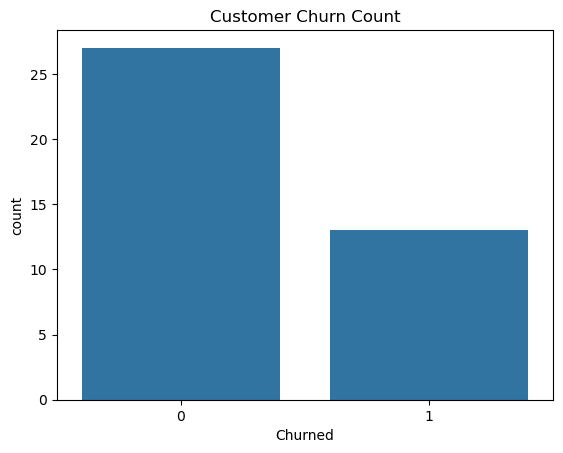

In [43]:
sns.countplot(x="Churned", data=df)
plt.title("Customer Churn Count")
plt.show()


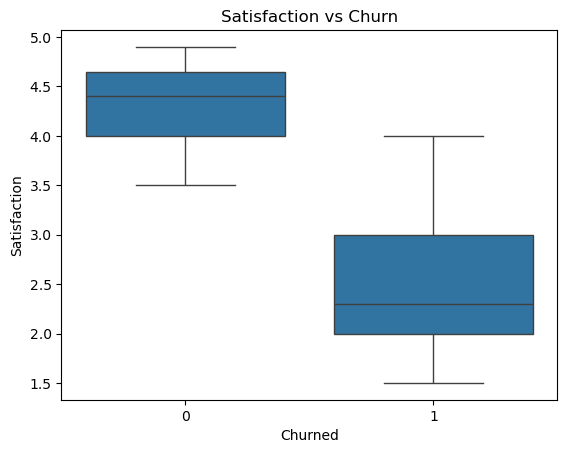

In [46]:
sns.boxplot(x="Churned", y="Satisfaction", data=df)
plt.title("Satisfaction vs Churn")
plt.show()

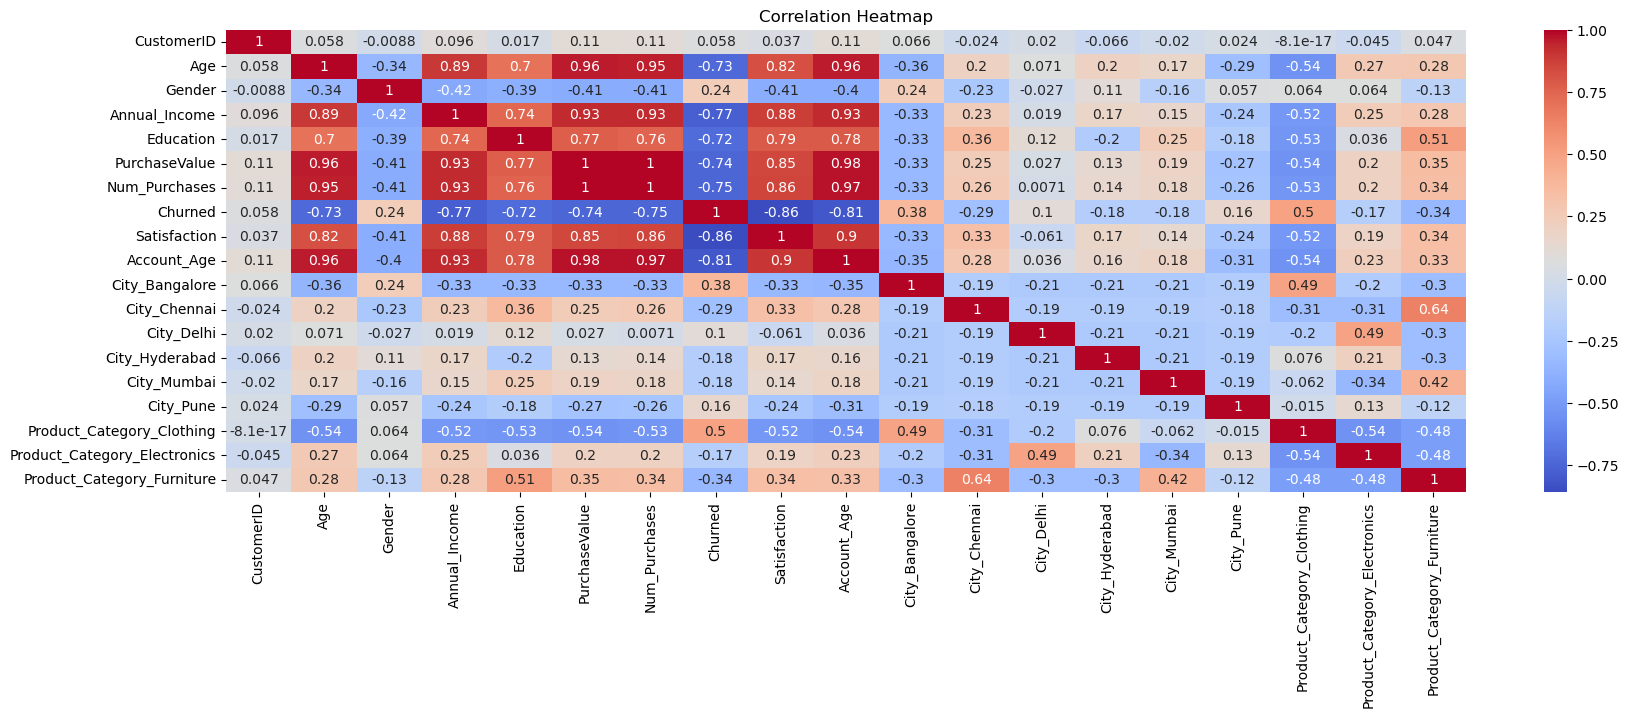

In [49]:
plt.figure(figsize=(20,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

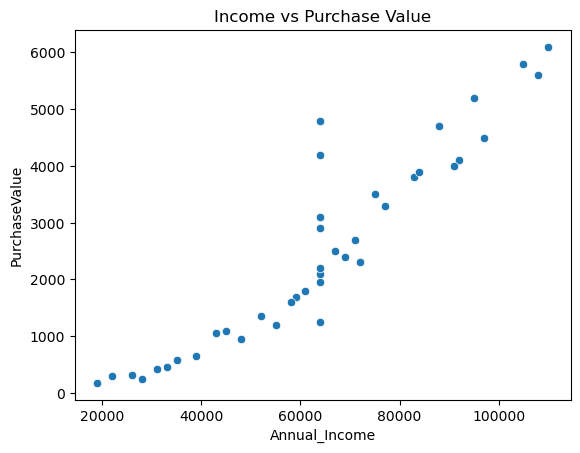

In [52]:
sns.scatterplot(x="Annual_Income", y="PurchaseValue", data=df)
plt.title("Income vs Purchase Value")
plt.show()

In [50]:
df.dtypes

CustomerID                        int64
Age                             float64
Gender                          float64
Annual_Income                   float64
Education                         int64
PurchaseValue                   float64
Num_Purchases                     int64
Churned                           int64
Satisfaction                    float64
Account_Age                       int64
City_Bangalore                    int64
City_Chennai                      int64
City_Delhi                        int64
City_Hyderabad                    int64
City_Mumbai                       int64
City_Pune                         int64
Product_Category_Clothing         int64
Product_Category_Electronics      int64
Product_Category_Furniture        int64
dtype: object